In [1]:
import cv2 as cv

import util as utils

In [2]:
video_path = 'material/focus_video.mov'

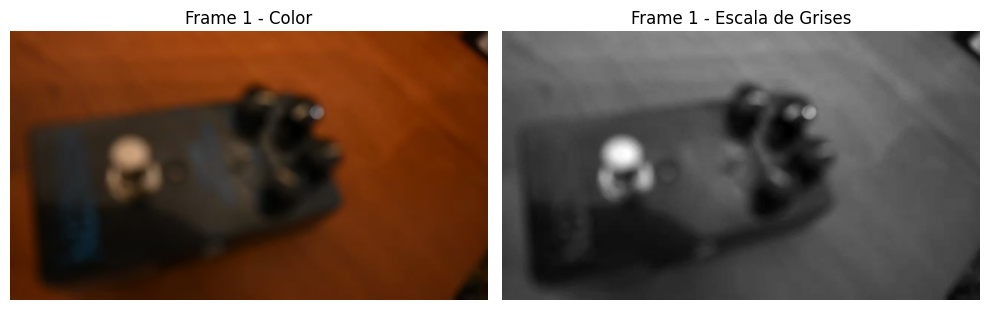

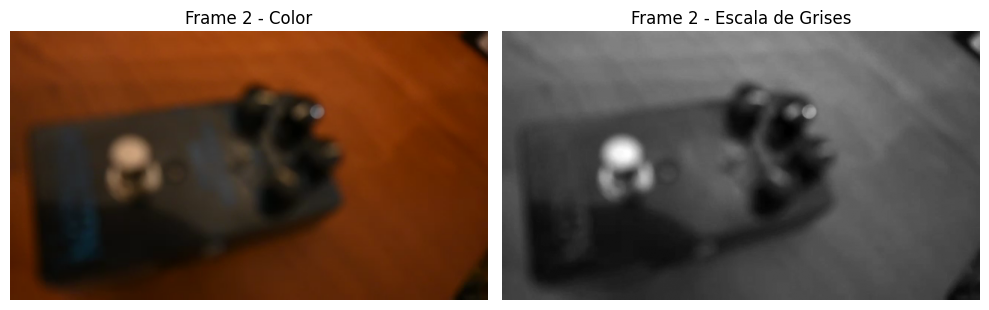

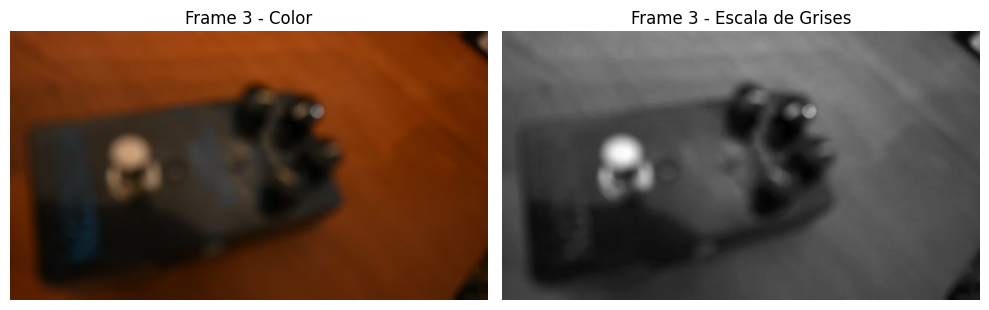

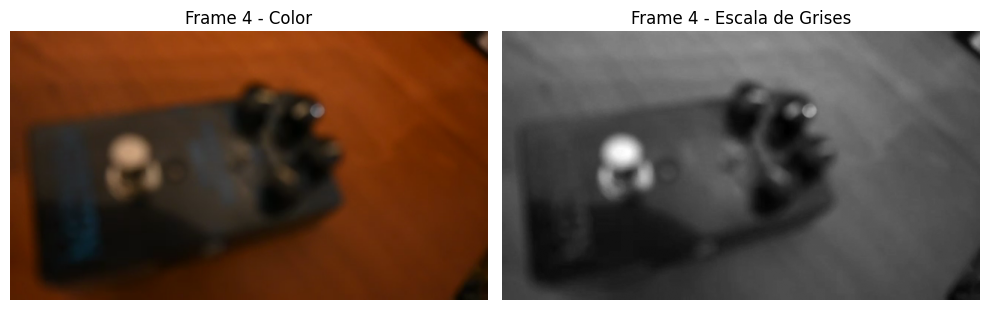

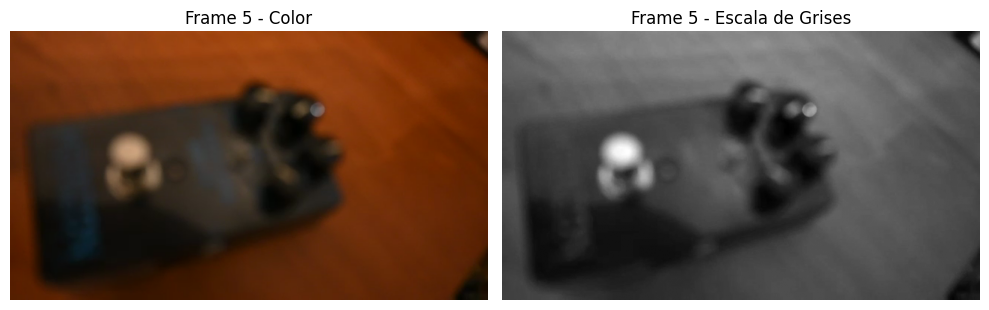

In [3]:
utils.show_n_frames(video_path, 5)

In [13]:
captura_video = cv.VideoCapture(video_path)

if captura_video.isOpened():
    # Obtiene dimensiones del video
    frame_width = int(captura_video.get(cv.CAP_PROP_FRAME_WIDTH))
    frame_height = int(captura_video.get(cv.CAP_PROP_FRAME_HEIGHT))
    new_width = frame_width // 2
    new_height = frame_height // 2
    
    # Obtiene la tasa de cuadros por segundo
    fps = int(captura_video.get(cv.CAP_PROP_FPS))
    delay = int(600 / fps)
    
    while True:
        ret, frame = captura_video.read()
        if not ret:
            break
    
        # Redimensionar frame a la mitad
        frame_resized = cv.resize(frame, (new_width, new_height))
    
        # Mostrar frame
        cv.imshow('Video', frame_resized)
    
        # Salir con la tecla 'q'
        if cv.waitKey(delay) & 0xFF == ord('q'):
            break
    
    # Liberar recursos
    captura_video.release()
    cv.destroyAllWindows()
    cv.waitKey(1)

CSV exportado a: material/fmfrecuencia_fm.csv
Gráfico guardado como: material/fmfrecuencia_fm.png


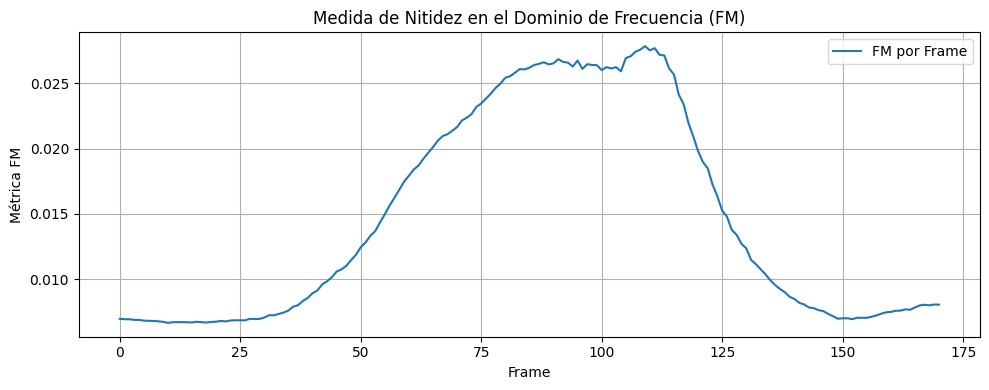

Mostrando los 3 frames con menor FM:


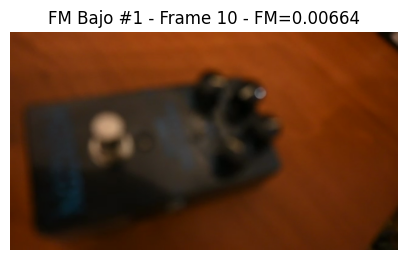

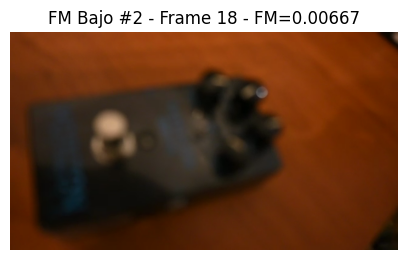

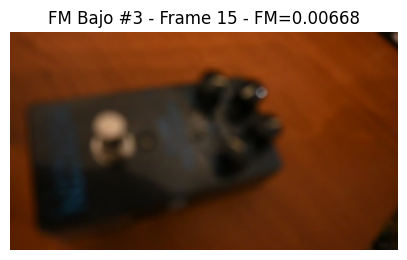

Mostrando los 3 frames con mayor FM:


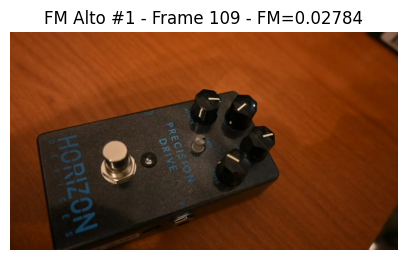

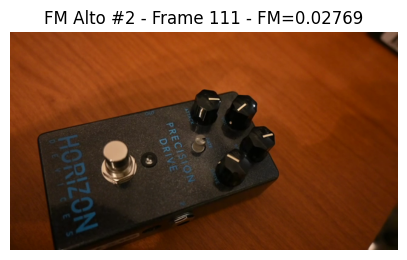

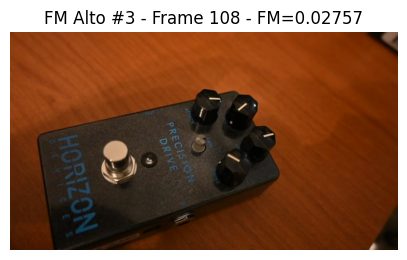

In [4]:
fm_values, frames_processed = utils.process_video(video_path)

if fm_values is not None:
    utils.export_and_plot_fm(fm_values, "material/fm")
    utils.show_extreme_frames(fm_values, frames_processed, n=3)